# AI Wildlife Detection

## Exploratory Data Analysis

In [29]:
import requests

url = "https://lilawildlife.blob.core.windows.net/lila-wildlife/oregon-critters/oregon_critters.zip"

with requests.get(url, stream=True) as r:
    with open("oregon.zip", "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

In [30]:
import zipfile

zf = zipfile.ZipFile("oregon.zip")
zf.namelist()[:20]  # preview contents

['oregon_critters.json']

In [31]:
import zipfile
import json

with zipfile.ZipFile("oregon.zip", "r") as zf:
    with zf.open("oregon_critters.json") as f:
        data = json.load(f)

type(data)

dict

In [32]:
if isinstance(data, dict):
    print(data.keys())
elif isinstance(data, list):
    print("Top level is a list")
    print("Length:", len(data))
    print("First item keys:", data[0].keys() if len(data) > 0 and isinstance(data[0], dict) else type(data[0]))

dict_keys(['info', 'images', 'annotations', 'categories'])


In [33]:
for k, v in data.items():
    if isinstance(v, list):
        print(k, len(v))

images 99909
annotations 102014
categories 46


In [34]:
# print cats
cat_ids = {c["id"]: c["name"] for c in data["categories"]}
print("Categories:")
for cat_id, cat_name in cat_ids.items():
    print(f"{cat_id}: {cat_name}")

Categories:
0: empty
1: coyote
2: bat species
3: strigidae family
4: ruffed grouse
5: red fox
6: canada jay
7: pileated woodpecker
8: reptile or amphibian
9: bobcat
10: marten
11: california ground squirrel
12: mink
13: western spotted skunk
14: mountain beaver
15: black bear
16: black-tailed deer
17: cougar
18: roosevelt elk
19: stellers jay
20: catharus species
21: varied thrush
22: dark-eyed junco
23: american robin
24: leporidae family
25: douglas squirrel
26: humboldt's flying squirrel
27: townsend's chipmunk
28: weasel family
29: parulidae family
30: invertebrate
31: picidae family
32: neotoma species
33: poecile species
34: virginia opossum
35: troglodytidae family
36: mountain quail
37: northern raccoon
38: striped skunk
39: western gray squirrel
40: northern flicker
41: domestic dog
42: human
43: small mammal
44: gray fox
45: other bird


In [35]:
target_class_ids = {
    0, # empty
    1, 8, 11, 13, 23, 24, 30, 37, 38, 41, 42, 43, 44, 45
}

In [36]:
filtered_annotations = [
    ann for ann in data["annotations"]
    if ann["category_id"] in target_class_ids
]

print("Annotations kept:", len(filtered_annotations))

Annotations kept: 28001


In [37]:
image_ids = {ann["image_id"] for ann in filtered_annotations}

print("Unique images:", len(image_ids))

Unique images: 27646


In [38]:
filtered_images = [
    img for img in data["images"]
    if img["id"] in image_ids
]

print("Images kept:", len(filtered_images))

Images kept: 27646


In [39]:
filtered_categories = [
    cat for cat in data["categories"]
    if cat["id"] in target_class_ids
]

In [40]:
subset_data = {
    "images": filtered_images,
    "annotations": filtered_annotations,
    "categories": filtered_categories
}

In [41]:
import json

with open("oregon_filtered.json", "w") as f:
    json.dump(subset_data, f)

print("Saved filtered dataset")

Saved filtered dataset


In [42]:
print(filtered_images[0])

{'location': 'COA_NA', 'datetime': '2019-08-15 14:11:33', 'split': 'train', 'width': 3840, 'height': 2880, 'file_name': 'COA_2019/COA_2019_empty/images/10022-1__2019-08-15__14-11-33(1).JPG', 'id': 'COA_2019/COA_2019_empty/images/10022-1__2019-08-15__14-11-33(1).JPG', 'sequence_level_annotation': False}


In [43]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

base_url = "https://lilawildlife.blob.core.windows.net/lila-wildlife/oregon-critters/"
out_dir = "images_subset"
os.makedirs(out_dir, exist_ok=True)

session = requests.Session()

def download_one(img):
    url = base_url + img["file_name"]
    path = os.path.join(out_dir, img["file_name"])
    tmp_path = path + ".part"

    if os.path.exists(path):
        return True, img["file_name"], "skipped"

    os.makedirs(os.path.dirname(path), exist_ok=True)

    try:
        r = session.get(url, timeout=20, stream=True)
        r.raise_for_status()

        with open(tmp_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        os.replace(tmp_path, path)
        return True, img["file_name"], None

    except Exception as e:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        return False, img["file_name"], str(e)

max_workers = 16

to_download = [
    img for img in filtered_images
    if not os.path.exists(os.path.join(out_dir, img["file_name"]))
]

results_ok = 0
results_fail = 0
results_skip = len(filtered_images) - len(to_download)

with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(download_one, img) for img in to_download]

    with tqdm(total=len(filtered_images), desc="Downloading", unit="img") as pbar:
        pbar.update(results_skip)
        pbar.set_postfix(ok=results_ok, fail=results_fail, skip=results_skip)

        for fut in as_completed(futures):
            ok, name, err = fut.result()
            if ok:
                results_ok += 1
            else:
                results_fail += 1

            pbar.set_postfix(ok=results_ok, fail=results_fail, skip=results_skip)
            pbar.update(1)

print("Done:", results_ok, "ok,", results_fail, "failed,", results_skip, "skipped")

Downloading: 100%|██████████| 27646/27646 [14:13<00:00, 32.39img/s, fail=275, ok=8861, skip=18510]

Done: 8861 ok, 275 failed, 18510 skipped


missing values

In [55]:
import json, os

out_dir = "images_subset"

# Keep only images whose file exists on disk
valid_images = [
    img for img in filtered_images
    if os.path.exists(os.path.join(out_dir, img["file_name"]))
]

valid_ids = {img["id"] for img in valid_images}

valid_annotations = [
    ann for ann in filtered_annotations
    if ann["image_id"] in valid_ids
]

print(f"Images  before: {len(filtered_images):>6}  after: {len(valid_images):>6}  removed: {len(filtered_images) - len(valid_images)}")
print(f"Annotations     before: {len(filtered_annotations):>6}  after: {len(valid_annotations):>6}  removed: {len(filtered_annotations) - len(valid_annotations)}")

# Overwrite the JSON with the cleaned subset
subset_data_clean = {
    "images": valid_images,
    "annotations": valid_annotations,
    "categories": filtered_categories,
}

with open("oregon_filtered.json", "w") as f:
    json.dump(subset_data_clean, f)

# Update in-memory references so downstream cells stay consistent
filtered_images[:] = valid_images
filtered_annotations[:] = valid_annotations

print("oregon_filtered.json updated — missing-image rows removed.")

Images  before:  27646  after:  27371  removed: 275
Annotations     before:  28001  after:  27639  removed: 362
oregon_filtered.json updated — missing-image rows removed.


In [64]:
from PIL import Image
import os, random

sample_images = random.sample(filtered_images, min(1000, len(filtered_images)))

unique_dims = set()

for img in sample_images:
    path = os.path.join(out_dir, img["file_name"])

    if os.path.exists(path):
        try:
            with Image.open(path) as im:
                unique_dims.add(im.size)  # (width, height)
        except Exception:
            pass

# print distinct dimensions
for w, h in sorted(unique_dims):
    print(f"{w}x{h}")

print("Total distinct sizes:", len(unique_dims))

1920x1080
1920x1440
2048x1152
2048x1440
2048x1536
3264x2448
3776x2124
3840x2160
3840x2880
4000x3000
4416x3312
4608x3456
5280x3960
Total distinct sizes: 13


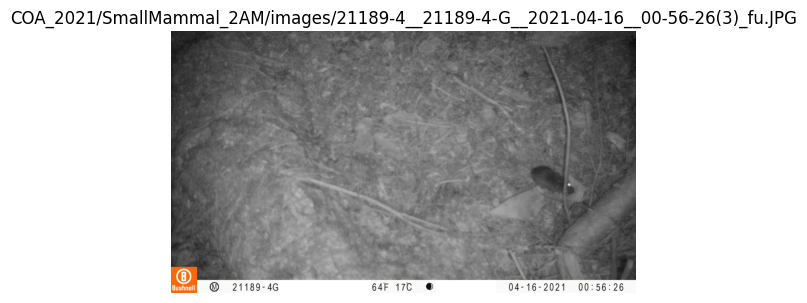

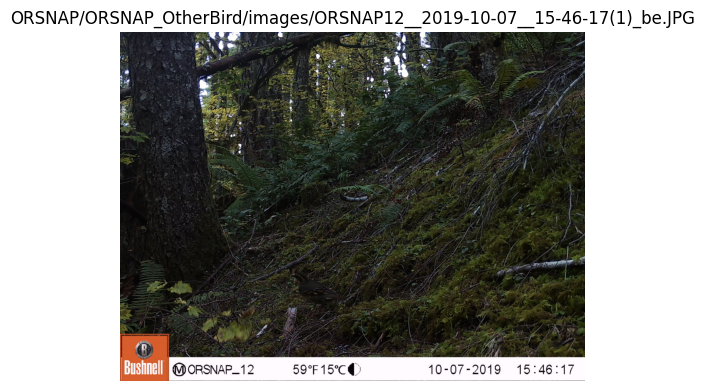

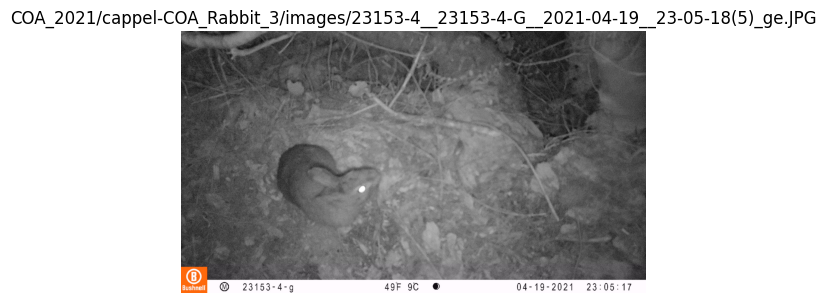

In [58]:
from PIL import Image
import matplotlib.pyplot as plt
import random, os

sample_images = random.sample(filtered_images, min(3, len(filtered_images)))

for img in sample_images:
    path = os.path.join(out_dir, img["file_name"])

    if os.path.exists(path):
        try:
            im = Image.open(path)
            plt.figure(figsize=(6, 6))
            plt.imshow(im)
            plt.title(img["file_name"])
            plt.axis("off")
            plt.show()
        except Exception as e:
            print(f"Error loading {img['file_name']}: {e}")
    else:
        print(f"Missing: {img['file_name']}")

## Preprocessing

In [66]:
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

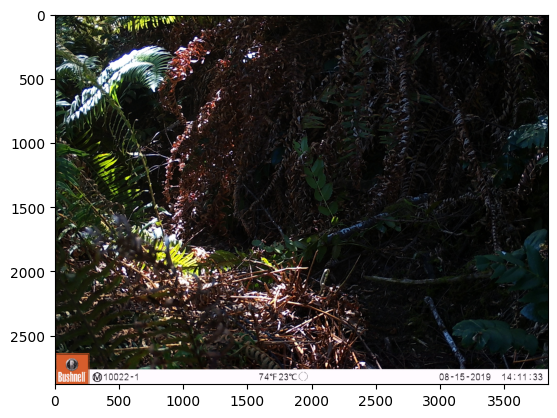

In [75]:
img0 = Image.open(os.path.join(out_dir, filtered_images[0]["file_name"]))
plt.imshow(img0)

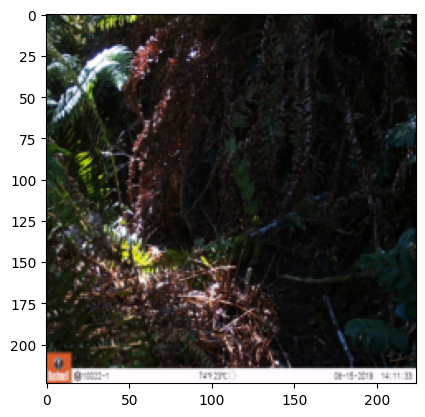

In [76]:
img = transform(img0)
plt.imshow(img.permute(1, 2, 0))  # CxHxW to HxWxC